<a href="https://colab.research.google.com/github/bukunmibalogun5-eng/Hugging-Face-and-Transformers/blob/main/Video_Models_Hugging_Faceipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import diffusers
import transformers
import cv2

Generating Video with Diffusion

In [2]:
from diffusers import StableVideoDiffusionPipeline

In [3]:
pipe = StableVideoDiffusionPipeline.from_pretrained("stabilityai/stable-video-diffusion-img2vid-xt",
                                                    torch_dtype=torch.float16,
                                                    variant="fp16")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

In [4]:
pipe

StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.40.0",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

In [5]:
path = "elmo.jpg"

In [6]:
path

'elmo.jpg'

In [7]:
from diffusers.utils import load_image, export_to_video

In [8]:
image = load_image(path)

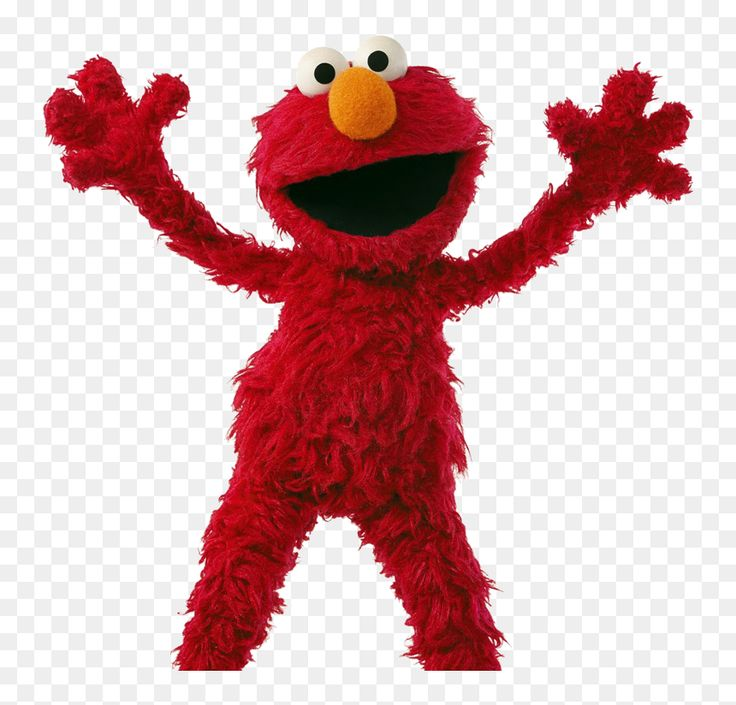

In [9]:
image

In [10]:
pipe.enable_model_cpu_offload()

In [11]:
generator = torch.manual_seed(42)

In [13]:
generator

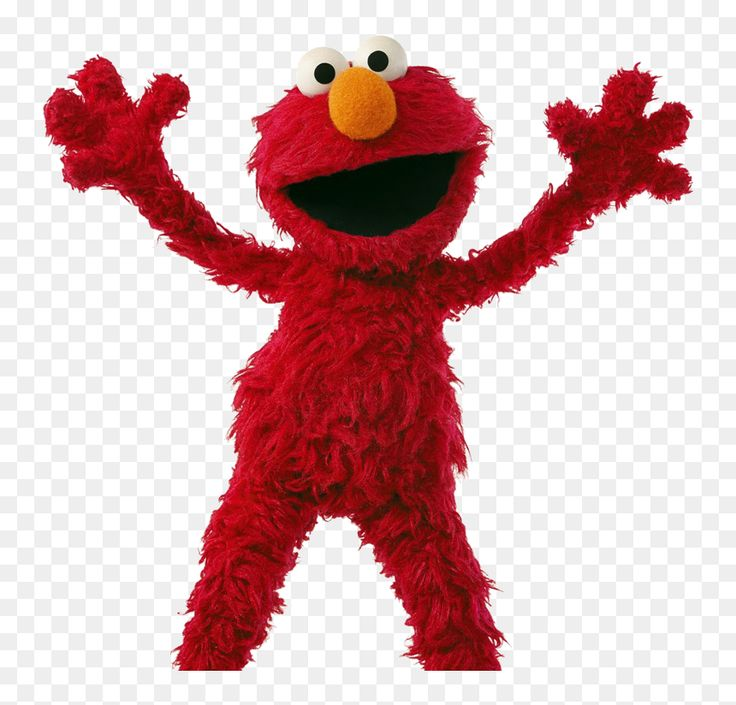

In [14]:
image

In [15]:
frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


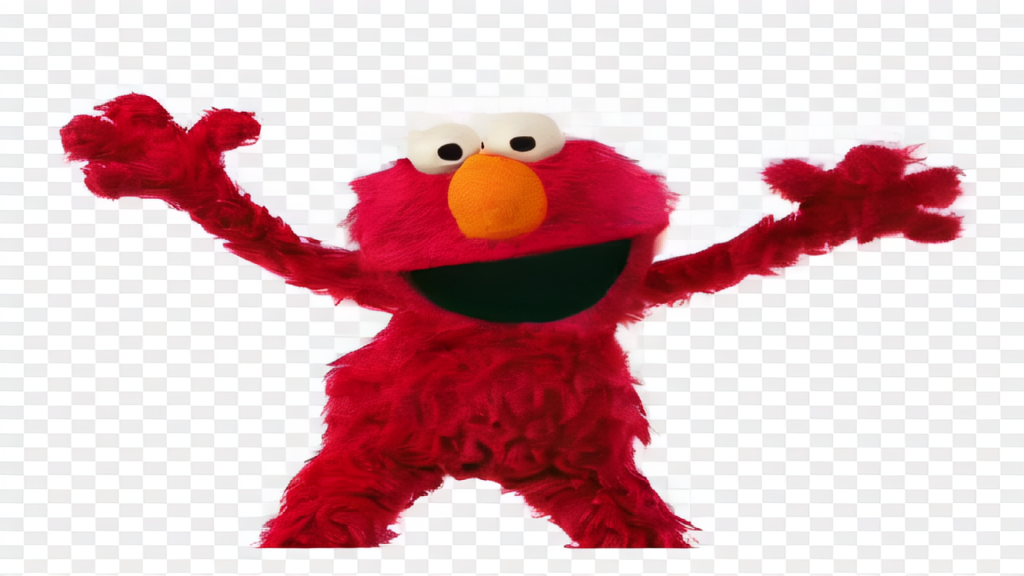

In [16]:
frames[5]

In [17]:
frames

[<PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image im

In [18]:
export_to_video(frames, "elmo.mp4", fps=7) # Frames per second

'elmo.mp4'